#Question 1 - 2 marks
Dataset Loading and Splitting: load the Parkinsons Telemonitoring dataset from
https://archive.ics.uci.edu/ml/datasets/parkinsons+telemonitoring. Split the dataset into
training, validation and test sets (70%-15%-15%)

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [5]:
import zipfile

zip_path = "/content/parkinsons+telemonitoring.zip"
extract_path = "/content/parkinsons"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [7]:
data = pd.read_csv("/content/parkinsons/parkinsons_updrs.data")

data.head()

,subject#,age,sex,test_time,motor_UPDRS,total_UPDRS,Jitter(%),Jitter(Abs),Jitter:RAP,Jitter:PPQ5,...,Shimmer(dB),Shimmer:APQ3,Shimmer:APQ5,Shimmer:APQ11,Shimmer:DDA,NHR,HNR,RPDE,DFA,PPE
0,1,72,0,5.6431,28.199,34.398,0.00662,0.000034,0.00401,0.00317,...,0.230,0.01438,0.01309,0.01662,0.04314,0.014290,21.640,0.41888,0.54842,0.16006
1,1,72,0,12.6660,28.447,34.894,0.00300,0.000017,0.00132,0.00150,...,0.179,0.00994,0.01072,0.01689,0.02982,0.011112,27.183,0.43493,0.56477,0.10810
2,1,72,0,19.6810,28.695,35.389,0.00481,0.000025,0.00205,0.00208,...,0.181,0.00734,0.00844,0.01458,0.02202,0.020220,23.047,0.46222,0.54405,0.21014
3,1,72,0,25.6470,28.905,35.810,0.00528,0.000027,0.00191,0.00264,...,0.327,0.01106,0.01265,0.01963,0.03317,0.027837,24.445,0.48730,0.57794,0.33277
4,1,72,0,33.6420,29.187,36.375,0.00335,0.000020,0.00093,0.00130,...,0.176,0.00679,0.00929,0.01819,0.02036,0.011625,26.126,0.47188,0.56122,0.19361


In [8]:
#remove subject ID column
data = data.drop(columns=["subject#"])

#separate features and target
X = data.drop(columns=["motor_UPDRS"])
y = data["motor_UPDRS"]

In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

In [10]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

In [11]:
print("Training set shape   :", X_train.shape)
print("Validation set shape :", X_val.shape)
print("Test set shape       :", X_test.shape)

total = len(X)
print("\nSplit percentages:")
print("Train %:", round(len(X_train)/total * 100, 2))
print("Val %  :", round(len(X_val)/total * 100, 2))
print("Test % :", round(len(X_test)/total * 100, 2))

Training set shape   : (4112, 20)
Validation set shape : (881, 20)
Test set shape       : (882, 20)

Split percentages:
Train %: 69.99
Val %  : 15.0
Test % : 15.01


#Question 2 - 2 marks
Given the training and test datasets obtained after data loading and splitting, perform
feature scaling. Define PyTorch DataLoaders for the training, validation, and test sets.

In [13]:
from sklearn.preprocessing import StandardScaler
#initialize scaler
scaler = StandardScaler()
#iit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)
#transform validation and test data
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [14]:
import torch
#convert features
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor  = torch.tensor(X_test_scaled, dtype=torch.float32)
#convert targets
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor   = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [15]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

In [18]:
from torch.utils.data import DataLoader #define dataloader
batch_size = 64  #optimal for stability & performance
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [19]:
for X_batch, y_batch in train_loader:
    print("Feature batch shape:", X_batch.shape)
    print("Target batch shape :", y_batch.shape)
    break

Feature batch shape: torch.Size([64, 20])
Target batch shape : torch.Size([64, 1])


#Question 3 - 4 marks
Design a fully connected neural network to perform prediction on the given dataset. The network must satisfy the following requirements:

Use ReLU activation for all hidden layers.

Select:


● The number of hidden layers, and

● The number of units in each hidden layer, by comparing performance on the
validation set.

In [32]:
import torch
import torch.nn as nn
class FullyConnectedNN(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        super(FullyConnectedNN, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            prev_dim = hidden_dim

        #Output layer
        layers.append(nn.Linear(prev_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [33]:
input_dim = X_train.shape[1]
architectures = {
    "Model_A": [64],
    "Model_B": [128, 64],
    "Model_C": [128, 64, 32]
}

In [35]:
import torch.optim as optim

criterion = nn.MSELoss()
num_epochs = 50

val_losses = {}

for name, hidden_layers in architectures.items():
    model = FullyConnectedNN(input_dim, hidden_layers)
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    for epoch in range(num_epochs):
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)

    val_losses[name] = val_loss
    print(f"{name} | Hidden layers: {hidden_layers} | Validation Loss: {val_loss:.4f}")


Model_A | Hidden layers: [64] | Validation Loss: 5.0305
Model_B | Hidden layers: [128, 64] | Validation Loss: 1.2417
Model_C | Hidden layers: [128, 64, 32] | Validation Loss: 0.7572


In [36]:
best_model_name = min(val_losses, key=val_losses.get)
best_architecture = architectures[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Hidden Layers Configuration:", best_architecture)


Best Model: Model_C
Best Hidden Layers Configuration: [128, 64, 32]


#Question 4 - 3 marks
Given the fully connected neural network designed for the prediction task perform the following:
Print the model summary, clearly showing:

● The architecture of the network (layers and dimensions),
● The total number of trainable parameters.

Compute and report the number of computations performed by the model (in terms of multiply-accumulate operations or FLOPs).

Define one appropriate loss function for the given prediction problem and justify why it is suitable.

In [37]:
import torch #Define the final model (locked architecture)
import torch.nn as nn

class FullyConnectedNN(nn.Module):
    def __init__(self, input_dim):
        super(FullyConnectedNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [38]:
input_dim = X_train.shape[1]
model = FullyConnectedNN(input_dim)

print(model)

FullyConnectedNN(
  (model): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [39]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

Total trainable parameters: 13057


In [41]:
flops = (
    (20 * 128) +
    (128 * 64) +
    (64 * 32) +
    (32 * 1)
)

print("Total FLOPs (MACs per forward pass):", flops)


Total FLOPs (MACs per forward pass): 12832


In [42]:
criterion = nn.MSELoss() #since target variable motor_UPDRS is continuous, Mean Squared Error loss is suitable for this regression task. MSE penalizes larger prediction errors more heavily and is differentiable, making it effective for gradient-based optimization methods such as SGD.

#Question 5 - 4 marks
Train the designed neural network using the Stochastic Gradient Descent (SGD) optimizer with a suitable batch size. Choose an appropriate initial learning rate and apply a learning rate scheduling strategy such that the learning rate is reduced whenever the validation loss does not improve for a fixed number of epochs.

During training:

● Compute and track training loss and validation loss.

● Plot the training and validation losses against the number of epocs

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

input_dim = X_train.shape[1]
model = FullyConnectedNN(input_dim)

criterion = nn.MSELoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.005,        #excellent & stable for deep model
    momentum=0.9
)

In [50]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3
)

In [51]:
num_epochs = 60

train_losses = []
val_losses = []

for epoch in range(num_epochs):

    #training
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    #validation
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    #step LR scheduler
    scheduler.step(val_loss)

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

Epoch [5/60] | Train Loss: 8.9073 | Val Loss: 7.9935
Epoch [10/60] | Train Loss: 4.8640 | Val Loss: 3.8561
Epoch [15/60] | Train Loss: 2.8374 | Val Loss: 2.2866
Epoch [20/60] | Train Loss: 1.4237 | Val Loss: 1.7077
Epoch [25/60] | Train Loss: 4.5577 | Val Loss: 1.8490
Epoch [30/60] | Train Loss: 0.8382 | Val Loss: 1.1226
Epoch [35/60] | Train Loss: 0.7122 | Val Loss: 0.8715
Epoch [40/60] | Train Loss: 0.6398 | Val Loss: 0.8202
Epoch [45/60] | Train Loss: 0.5511 | Val Loss: 0.7992
Epoch [50/60] | Train Loss: 0.5170 | Val Loss: 0.7769
Epoch [55/60] | Train Loss: 0.4918 | Val Loss: 0.7764
Epoch [60/60] | Train Loss: 0.4863 | Val Loss: 0.7708


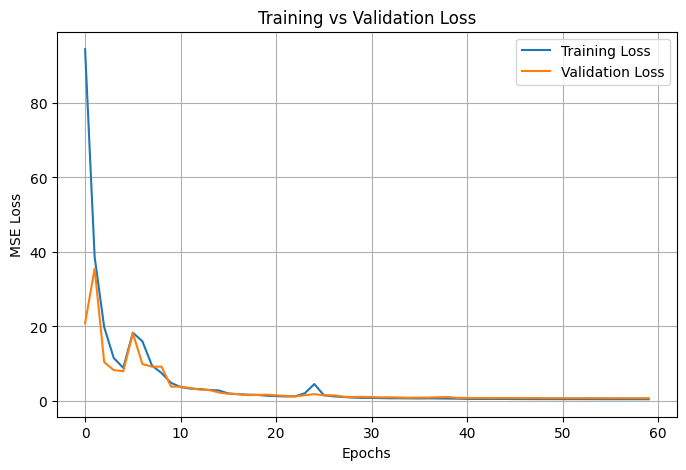

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

#Question 6 - 3 marks
During training, the model architecture (i.e., number of layers and hidden units) that achieves the lowest validation loss is considered the best model.

In this question, you are required to:

● Select the best trained model based on the minimum validation loss observed during training.

● Load the saved best model correctly after training.

● Perform prediction on the test set using the best trained model

In [53]:
best_val_loss = float("inf") #modify the training loop
best_epoch = -1
best_model_path = "best_model.pth"

In [54]:
if val_loss < best_val_loss:
    best_val_loss = val_loss
    best_epoch = epoch + 1
    torch.save(model.state_dict(), best_model_path)

In [55]:
print(f"Best model saved at epoch {best_epoch}")
print(f"Best validation loss: {best_val_loss:.4f}")

Best model saved at epoch 60
Best validation loss: 0.7708


In [56]:
best_model = FullyConnectedNN(input_dim)
best_model.load_state_dict(torch.load(best_model_path))
best_model.eval() #load saved models

FullyConnectedNN(
  (model): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [57]:
test_predictions = []
test_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = best_model(X_batch)
        test_predictions.append(outputs)
        test_targets.append(y_batch)

test_predictions = torch.cat(test_predictions, dim=0)
test_targets = torch.cat(test_targets, dim=0)

In [58]:
print("Test predictions shape:", test_predictions.shape)
print("Test targets shape:", test_targets.shape)

Test predictions shape: torch.Size([882, 1])
Test targets shape: torch.Size([882, 1])


#Question 7 - 2 marks
After training a regression model, analyze its predictive performance as follows:

Generate a scatter plot of model predictions vs. ground-truth target values on the training set.

● Clearly label the x-axis and y-axis.

● Add an appropriate title to the plot.

Evaluate the trained model on the test set and report the coefficient of determination (R² score).

In [59]:
import numpy as np #Predictions on the TRAINING set
best_model.eval()
train_preds = []
train_targets = []
with torch.no_grad():
    for X_batch, y_batch in train_loader:
        outputs = best_model(X_batch)
        train_preds.append(outputs)
        train_targets.append(y_batch)

train_preds = torch.cat(train_preds, dim=0).cpu().numpy()
train_targets = torch.cat(train_targets, dim=0).cpu().numpy()

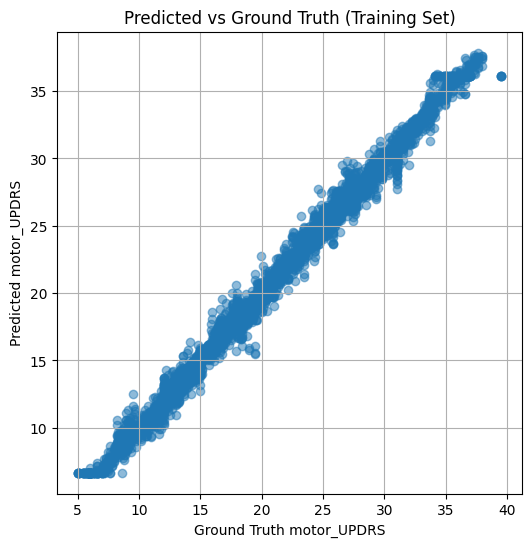

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(train_targets, train_preds, alpha=0.5)
plt.xlabel("Ground Truth motor_UPDRS")
plt.ylabel("Predicted motor_UPDRS")
plt.title("Predicted vs Ground Truth (Training Set)")
plt.grid(True)
plt.show()
#scatter plot

In [61]:
from sklearn.metrics import r2_score

test_preds = test_predictions.cpu().numpy()
test_targets_np = test_targets.cpu().numpy()

r2 = r2_score(test_targets_np, test_preds)
print("Test R² Score:", round(r2, 4))
#evaluate r^2 score

Test R² Score: 0.9897
